In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/drive/My Drive/household_energy_consump/uk_data_clean.csv')
pivoted = df.pivot(index='datetime', columns='id', values='target')
def dtarg(x):
  return(pd.to_datetime(x,format='%Y-%m-%d %H:%M:%S'))
pivoted.index = pivoted.index.map(dtarg)
np.random.seed(216)
testcols = np.random.choice(pivoted.columns, size=int((len(pivoted.columns)*.2)//1), replace=False, p=None)
traincols = [x for x in pivoted.columns if x not in testcols]
energy = pivoted[traincols]
energy_testing_set = pivoted[testcols]

Methods of clustering the households:
1. Reduce the dimension of each household from 18960 to 395, i.e., one data point per day to represent the time series and then run kmeans
    
    Dimension reduction techniques to try:

    (a) piecewise aggregation approximation (PAA), which is to take the average over fixed-sized windows - in our case every 1 day.

    (b)in stead of the average per window, simply pick a data point per window as the representative. maybe we can change the representative and see if the clustering performance inproves?

    Note: reducing the dimension to 395 might still be too large for kmeans. We should try to reduce to even smaller dimensions and see if the clustering performance is acceptable.

    How to measure clustering performance?

    Since our data is high dimensional, the typical evaluation techniques for kmeans don't work (eg. elbow method, Silhouette Score). We could still use these methods to evaluate clustering performance on the reduced data, but for the full dimensional data, we could either try visualize it and observe if the selected centroids are representative or run the clustering algorithm multiple times and see if it provides similar results.


In [ ]:
!pip install pyts
from pyts.approximation import PiecewiseAggregateApproximation
from sklearn.cluster import KMeans


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.1 MB/s eta 0:00:00


In [ ]:
# First we try method 1(a): Reduce dimention of each household data to 395 using PAA
# PAA transformation
window_size = 48
paa = PiecewiseAggregateApproximation(window_size=window_size)
energy_paa = paa.transform(energy.T) # energy_paa is a np array of dimension (736, 395). Each row is a household and each column is the average over the 48 values for a day

# run k-mean on energy_paa
kmeans_paa = KMeans(n_clusters=10)
kmeans_paa.fit(energy_paa)
centroids_paa = kmeans_paa.cluster_centers_

date_list = list(dict.fromkeys([d.date() for d in energy.index]))

# Find the 10 real samples that are the closest to the found centroids
# this is neccessary because after paa we don't have the 30-min granulated data anymore and we need to find the real samples to recover the granulated data
from sklearn.metrics import pairwise_distances_argmin_min

closest_indices_paa, distances_paa = pairwise_distances_argmin_min(centroids_paa, energy_paa)

# Extract the actual samples
representative_samples_paa = energy_paa[closest_indices_paa]  # shape: (10, 300)
representative_samples = energy.iloc[:,closest_indices_paa]   # shape = (10, 18960)





In [ ]:
# Next we try method 1(b): Reduce dimention of each household data to 395 by selecting some value from each day

####### NEEDS Editing ########
# PAA transformation
window_size = 48
paa = PiecewiseAggregateApproximation(window_size=window_size)
energy_paa = paa.transform(energy.T) # energy_paa is a np array of dimension (736, 395). Each row is a household and each column is the average over the 48 values for a day

# run k-mean on energy_paa
kmeans_paa = KMeans(n_clusters=10)
kmeans_paa.fit(energy_paa)
centroids_paa = kmeans_paa.cluster_centers_

date_list = list(dict.fromkeys([d.date() for d in energy.index]))

# Find the 10 real samples that are the closest to the found centroids
# this is neccessary because after paa we don't have the 30-min granulated data anymore and we need to find the real samples to recover the granulated data
from sklearn.metrics import pairwise_distances_argmin_min

closest_indices_paa, distances_paa = pairwise_distances_argmin_min(centroids_paa, energy_paa)

# Extract the actual samples
representative_samples_paa = energy_paa[closest_indices_paa]  # shape: (10, 300)
representative_samples = energy.iloc[:,closest_indices_paa]   # shape = (10, 18960)





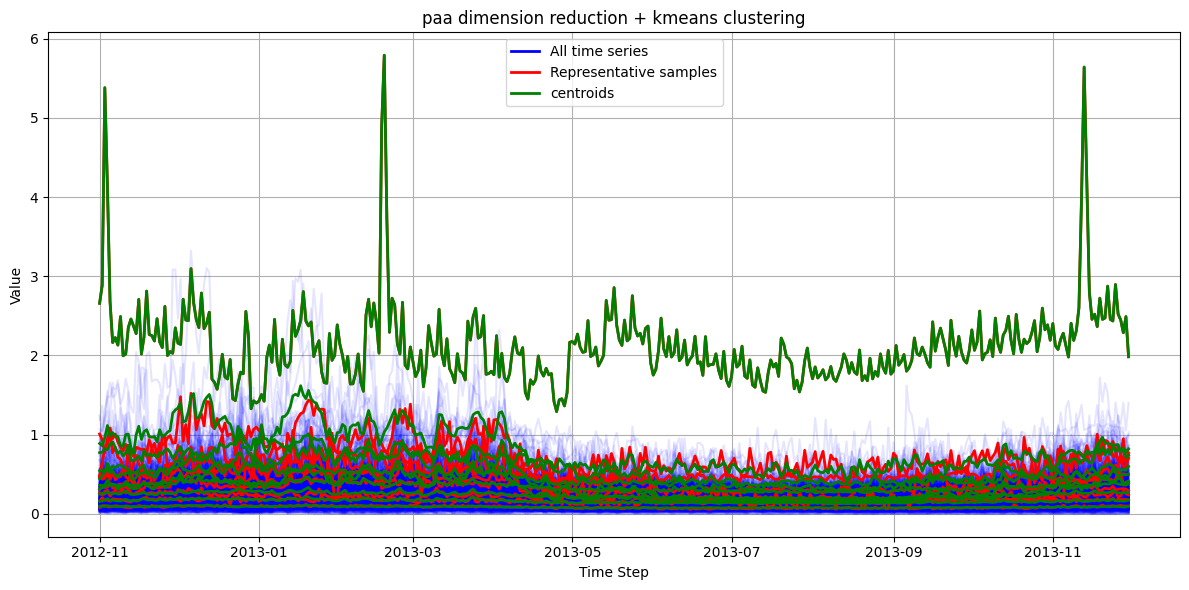

In [ ]:

# plot the result of paa + kmeans
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 6))

# Plot all 736 households in blue
for series in energy_paa:
    plt.plot(date_list,series, color='blue', alpha=0.1)


# Plot all 10 representative_samples in red
for center in representative_samples_paa:
    plt.plot(date_list, center, color='red', linewidth=2)

# Plot all 10 centroids in green
for center in centroids_paa:
    plt.plot(date_list, center, color='green', linewidth=2)

plt.title("paa dimension reduction + kmeans clustering")
plt.xlabel("Time Step")
plt.ylabel("Value")
# Create custom legend
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='All time series'),
    Line2D([0], [0], color='red', lw=2, label='Representative samples'),
    Line2D([0], [0], color='green', lw=2, label='centroids')
]
plt.legend(handles=legend_elements)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# # Pivot to wide format: each column = 1 household, this is for generalized LSTM model.
# pivot = df.pivot(index='datetime', columns='id', values='target')
# pivot = pivot.iloc[:, :10]  # Start with 10 households for memory safety, otherwise kernel crushes....


# in order to make the rest of Cisil's code compatible, assign values of representative_samples to the variable pivot.
import copy
pivot = copy.copy(representative_samples)

# Time features
tf = pd.DataFrame(index=pivot.index)
tf['hour'] = pivot.index.hour + pivot.index.minute / 60
tf['dow'] = pivot.index.dayofweek
tf['month'] = pivot.index.month

# Cyclical encoding, this way model understands how close 23:30 and 00:30 are...., we could possible have remove month versions.

tf['hour_sin'] = np.sin(2 * np.pi * tf['hour'] / 24)
tf['hour_cos'] = np.cos(2 * np.pi * tf['hour'] / 24)
tf['dow_sin'] = np.sin(2 * np.pi * tf['dow'] / 7)
tf['dow_cos'] = np.cos(2 * np.pi * tf['dow'] / 7)
tf['month_sin'] = np.sin(2 * np.pi * tf['month'] / 12)
tf['month_cos'] = np.cos(2 * np.pi * tf['month'] / 12)

time_features = tf[['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']].values

In [ ]:
input_window = 7 * 48       # 336
forecast_horizon = 1 * 48   # 48

total_samples = pivot.shape[0] - input_window - forecast_horizon

# Create raw data splits before scaling
split1 = int(0.7 * total_samples)
split2 = int(0.85 * total_samples)

# Raw splits, unscaled
pivot_np = pivot.values
train_raw = pivot_np[:split1 + input_window + forecast_horizon]
val_raw   = pivot_np[split1:split2 + input_window + forecast_horizon]
test_raw  = pivot_np[split2:]

In [ ]:
train_raw.shape

(13387, 10)

In [ ]:
# Fit scaler on training data
scaler = MinMaxScaler()
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

# Time features must also be split accordingly
tf_train = time_features[:split1 + input_window + forecast_horizon]
tf_val   = time_features[split1:split2 + input_window + forecast_horizon]
tf_test  = time_features[split2:]

In [ ]:
# Sequence creation function
def create_sequences(data, time_feats, input_window, forecast_horizon):
    X, y = [], []
    num_households = data.shape[1]
    for c in range(num_households):
        series = data[:, c]
        for i in range(len(series) - input_window - forecast_horizon):
            hist = series[i:i+input_window]
            tf_hist = time_feats[i:i+input_window, :]
            X.append(np.hstack([hist.reshape(-1, 1), tf_hist]))
            y.append(series[i+input_window:i+input_window+forecast_horizon].reshape(-1, 1))
    return np.array(X), np.array(y)

# Build sequences for each set
X_train, y_train = create_sequences(train_scaled, tf_train, input_window, forecast_horizon)
X_val, y_val     = create_sequences(val_scaled, tf_val, input_window, forecast_horizon)
X_test, y_test   = create_sequences(test_scaled, tf_test, input_window, forecast_horizon)

print("X_train shape:", X_train.shape)  # (samples, 336, 7)
print("y_train shape:", y_train.shape)  # (samples, 48, 1)

X_train shape: (130030, 336, 7)
y_train shape: (130030, 48, 1)


In [ ]:
print("X_val shape:", X_val.shape)  # (samples, 336, 7)
print("y_val shape:", y_val.shape)  # (samples, 48, 1)
print("X_test shape:", X_test.shape)  # (samples, 336, 7)
print("y_test shape:", y_test.shape)  # (samples, 48, 1)

X_val shape: (27860, 336, 7)
y_val shape: (27860, 48, 1)
X_test shape: (27870, 336, 7)
y_test shape: (27870, 48, 1)


In [ ]:
# LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

model = Sequential([
    LSTM(64, input_shape=(input_window, X_train.shape[2])),
    RepeatVector(forecast_horizon),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 48, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=2,
    batch_size=8,
    verbose=1
)

Epoch 1/2
16254/16254 ━━━━━━━━━━━━━━━━━━━━ 2145s 132ms/step - loss: 0.0113 - val_loss: 0.0051
Epoch 2/2
16254/16254 ━━━━━━━━━━━━━━━━━━━━ 2198s 133ms/step - loss: 0.0075 - val_loss: 0.0047


In [ ]:
# Save to local Colab first
model.save('/content/updated_lstm_energy_model.h5')

# Then copy it to your Google Drive
!cp /content/lstm_energy_model.h5 '/content/drive/My Drive/updated_lstm_energy_model.h5'


cp: cannot stat '/content/lstm_energy_model.h5': No such file or directory


In [ ]:
test_loss = model.evaluate(X_test, y_test)
print(f"Test MSE Loss: {test_loss:.6f}")


871/871 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - loss: 0.0054
Test MSE Loss: 0.007647


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 886ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


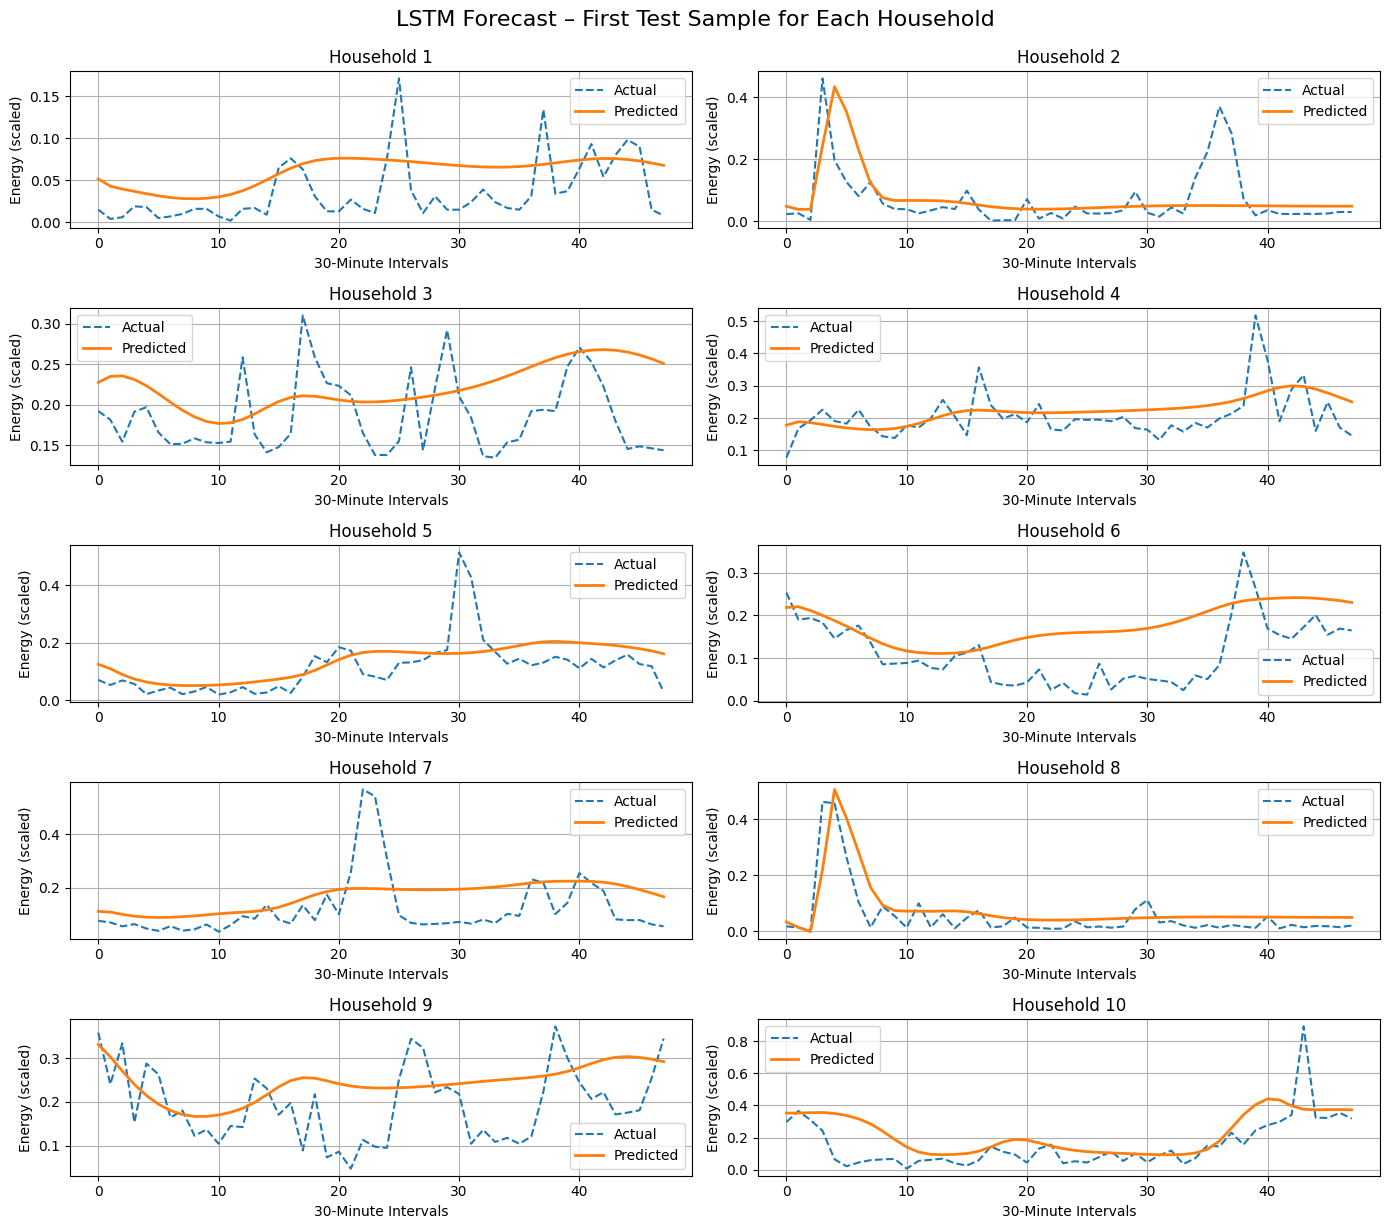

In [ ]:
import matplotlib.pyplot as plt

# Constants
num_households = pivot.shape[1]
sequences_per_household_test = len(X_test) // num_households

# Setup subplot grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 12))  # 10 households = 5 rows × 2 cols
axes = axes.flatten()

# Loop through households
for h in range(num_households):
    idx = h * sequences_per_household_test  # first test sample for household h

    y_pred = model.predict(X_test[idx:idx+1])[0].flatten()
    y_true = y_test[idx].flatten()

    ax = axes[h]
    ax.plot(y_true, linestyle='--', label='Actual')
    ax.plot(y_pred, linewidth=2, label='Predicted')
    ax.set_title(f'Household {h+1}')
    ax.set_xlabel("30-Minute Intervals")
    ax.set_ylabel("Energy (scaled)")
    ax.grid(True)
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.suptitle("LSTM Forecast – First Test Sample for Each Household", fontsize=16, y=1.02)
plt.show()


In [ ]:
#Use our already trained LSTM model to predict energy usage for the 11th household, which was not included in training.

In [ ]:
pivot = df.pivot(index='datetime', columns='id', values='target')
pivot_full = df.pivot(index='datetime', columns='id', values='target')
house11 = pivot_full.iloc[:, 10:11]  # 11th house (single column DataFrame)

In [ ]:
time_features_house11 = time_features  # already matches the full index


In [ ]:
scaler_h11 = MinMaxScaler()
house11_scaled = scaler_h11.fit_transform(house11)


In [ ]:
X_h11, y_h11 = create_sequences(house11_scaled, time_features_house11, input_window, forecast_horizon)

In [ ]:
y_h11.shape

(18576, 48, 1)

In [ ]:
y_h11_pred = model.predict(X_h11)

581/581 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step


In [ ]:
from sklearn.metrics import mean_squared_error
mse_h11 = mean_squared_error(y_h11.reshape(-1), y_h11_pred.reshape(-1))
print(f"Test MSE on Unseen 11th Household: {mse_h11:.4f}")

Test MSE on Unseen 11th Household: 0.0043


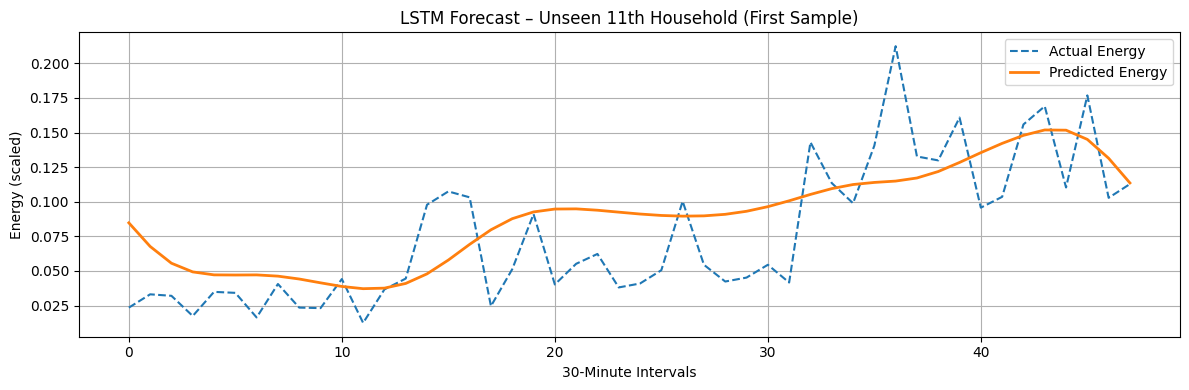

In [ ]:
import matplotlib.pyplot as plt

# First prediction is for the 1st day after first week of the dataset.
y_pred_11 = y_h11_pred[0].flatten()
y_true_11 = y_h11[0].flatten()

plt.figure(figsize=(12, 4))
plt.plot(y_true_11, label='Actual Energy', linestyle='--')
plt.plot(y_pred_11, label='Predicted Energy', linewidth=2)
plt.title("LSTM Forecast – Unseen 11th Household (First Sample)")
plt.xlabel("30-Minute Intervals")
plt.ylabel("Energy (scaled)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


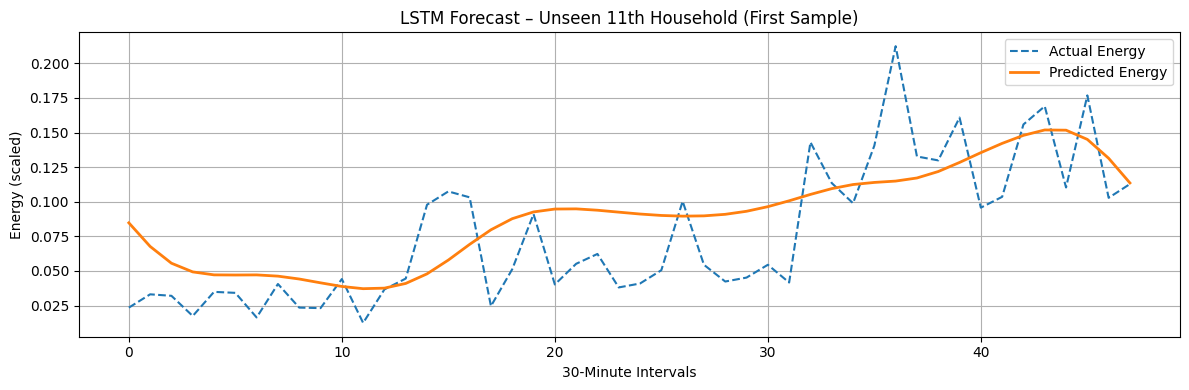

In [ ]:
y_pred_11 = y_h11_pred[0].flatten()
y_true_11 = y_h11[0].flatten()

plt.figure(figsize=(12, 4))
plt.plot(y_true_11, label='Actual Energy', linestyle='--')
plt.plot(y_pred_11, label='Predicted Energy', linewidth=2)
plt.title("LSTM Forecast – Unseen 11th Household (First Sample)")
plt.xlabel("30-Minute Intervals")
plt.ylabel("Energy (scaled)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Full pivot table
pivot_full = df.pivot(index='datetime', columns='id', values='target')

# Select 5 unseen households: columns 10 to 14 (11th to 15th house)
test_houses = pivot_full.iloc[:, 10:15]
num_new_houses = test_houses.shape[1]


In [ ]:
time_feats_test = time_features  # same index as pivot

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.preprocessing import MinMaxScaler

mse_list = []

for i in range(num_new_houses):
    house_data = test_houses.iloc[:, i:i+1]  # shape (T, 1)

    # Fit a new scaler for this unseen house
    scaler_house = MinMaxScaler()
    house_scaled = scaler_house.fit_transform(house_data)

    # Create sequences
    X_h, y_h = create_sequences(house_scaled, time_feats_test, input_window, forecast_horizon)

    # Make predictions
    y_pred = model.predict(X_h)

    # Compute MSE
    mse = mean_squared_error(y_h.reshape(-1), y_pred.reshape(-1))
    mse_list.append(mse)
    print(f"House {i+11} MSE: {mse:.4f}")  # i+11 to show actual column position


581/581 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step
House 11 MSE: 0.0043
581/581 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step
House 12 MSE: 0.0091
581/581 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step
House 13 MSE: 0.0038
581/581 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step
House 14 MSE: 0.0105
581/581 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step
House 15 MSE: 0.0051


In [ ]:
avg_mse = np.mean(mse_list)
print(f"\n✅ Average MSE across 5 unseen test houses: {avg_mse:.4f}")


✅ Average MSE across 5 unseen test houses: 0.0066


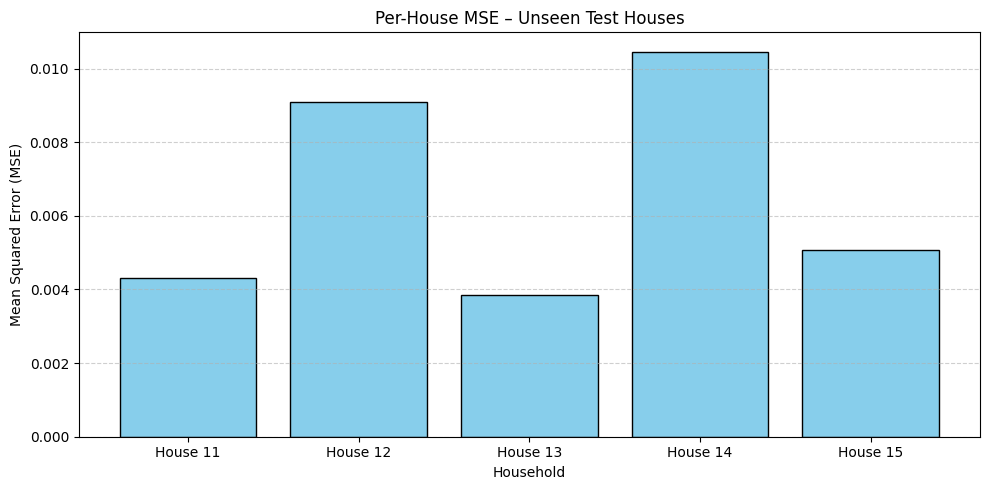

In [ ]:
import matplotlib.pyplot as plt

# House labels
house_labels = [f"House {i}" for i in range(11, 16)]

# Bar plot of MSEs
plt.figure(figsize=(10, 5))
plt.bar(house_labels, mse_list, color='skyblue', edgecolor='black')
plt.title("Per-House MSE – Unseen Test Houses")
plt.ylabel("Mean Squared Error (MSE)")
plt.xlabel("Household")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
for house, mse in zip(house_labels, mse_list):
    print(f"{house}: MSE = {mse:.4f}")


House 11: MSE = 0.0043
House 12: MSE = 0.0091
House 13: MSE = 0.0038
House 14: MSE = 0.0105
House 15: MSE = 0.0051
